<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab%2015/Lab_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

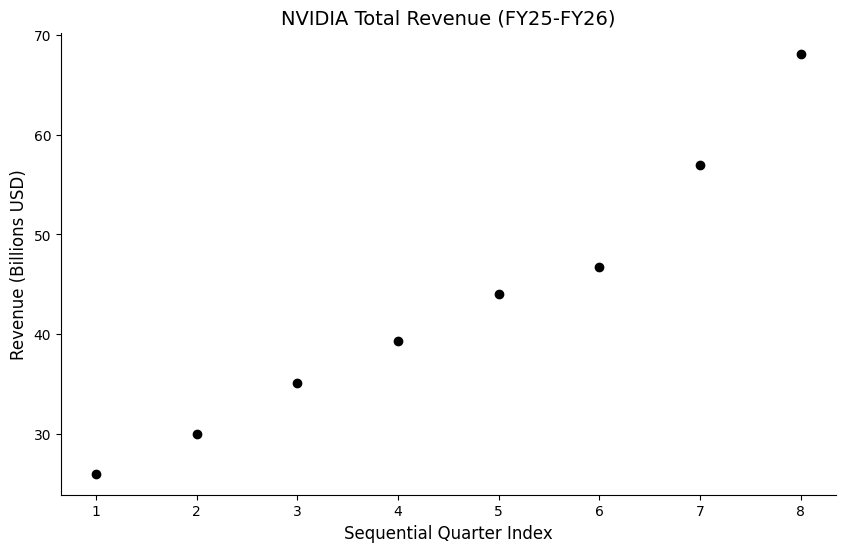

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

# Step 1: Ingestion of Modernized NVIDIA Dataset
# Data reflects the massive AI infrastructure capex boom of 2024-2026

data = {
    'Time_Index': np.array([1, 2, 3, 4, 5, 6, 7, 8]),
    'Total_Revenue_Billions': np.array([26.04, 30.04, 35.10, 39.33, 44.06, 46.74, 57.00, 68.10])
}
df = pd.DataFrame(data)

X = df[['Time_Index']]
y = df['Total_Revenue_Billions']

# Visual EDA (Adhering to Data-Ink Ratio principles)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.title('NVIDIA Total Revenue (FY25-FY26)', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

Linear Training MSE (High Bias): 7.91


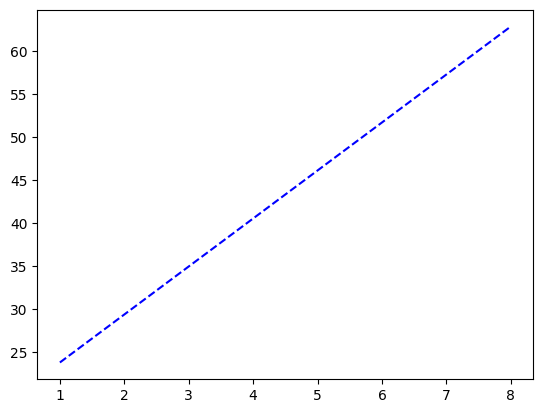

In [8]:
# Step 2: High Bias (Underfitting) Linear Model
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
mse_linear = mean_squared_error(y, y_pred_linear)

print(f"Linear Training MSE (High Bias): {mse_linear:.2f}")

plt.plot(X, y_pred_linear, color='blue', linestyle='--', label='Linear Fit (High Bias)')

Polynomial Degree-7 Training MSE (High Variance): 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


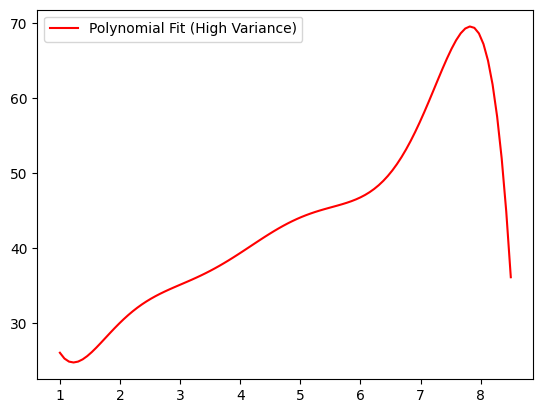

In [14]:
# Step 3: High Variance (Overfitting) Polynomial Model
poly_features = PolynomialFeatures(degree=7)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

y_pred_poly = poly_reg.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"Polynomial Degree-7 Training MSE (High Variance): {mse_poly:.2f}")

# Plotting the smooth polynomial curve
X_smooth = np.linspace(1, 8.5, 100).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth)
y_smooth_poly = poly_reg.predict(X_smooth_poly)

plt.plot(X_smooth, y_smooth_poly, color='red', label='Polynomial Fit (High Variance)')
plt.legend()
plt.show()

In [10]:
# Step 4: The Extrapolation Collapse
X_future = np.array([[9]])  # Forecasting Q1 FY27
X_future_poly = poly_features.transform(X_future)
future_pred = poly_reg.predict(X_future_poly)

print(f"\nHallucinated Q1 FY27 Revenue Prediction: ${future_pred[0]:.2f} Billion")


Hallucinated Q1 FY27 Revenue Prediction: $-84.00 Billion


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [11]:
# Step 5: K-Fold Cross Validation
cv_scores = cross_val_score(poly_reg, X_poly, y, cv=4, scoring='neg_mean_squared_error')
mean_cv_mse = -cv_scores.mean()

print(f"K-Fold Cross-Validated MSE (The True Operational Error): {mean_cv_mse:.2f}")

K-Fold Cross-Validated MSE (The True Operational Error): 8641.58


OVERFITTED MODEL (7th-degree OLS, α = 0)
  Training MSE : 0.1081  ← dangerously low
  4-Fold CV MSE: 0.1687  ← far higher = high variance
  Variance Gap : 0.0605

RIDGE MODEL: Best α selected by 4-Fold CV = 0.2477
  Training MSE : 0.1124
  4-Fold CV MSE: 0.1400
  Variance Gap : 0.0275

COEFFICIENT WEIGHT COMPARISON (|wⱼ|):
  Feature               OLS        Ridge    Shrinkage %
  x^1                 1.680        1.393          17.1%
  x^2                -0.385       -0.083          78.5%
  x^3                -1.329       -0.437          67.1%
  x^4                 0.994        0.187          81.2%
  x^5                 0.592       -0.343          41.9%
  x^6                -0.603       -0.081          86.5%
  x^7                -0.315       -0.011          96.7%



FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/ridge_regression_lab.png'

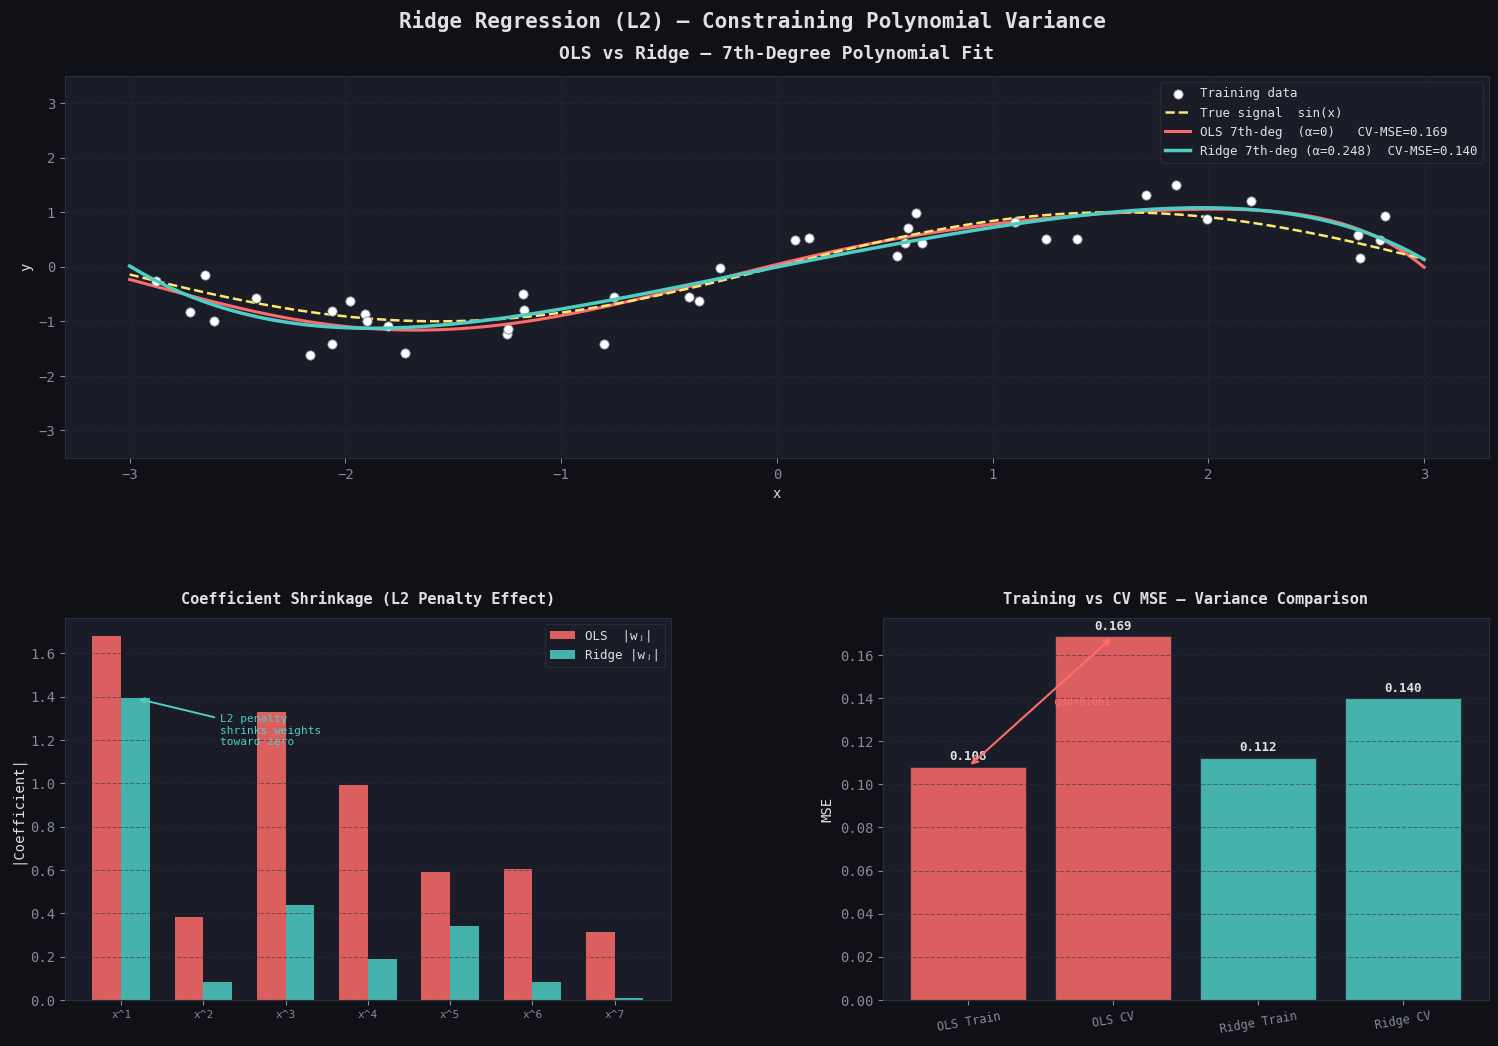

In [15]:
"""
Ridge Regression Lab: Taming Overfitted Polynomial Models with L2 Regularization
=================================================================================
Demonstrates how Ridge (L2) regularization constrains coefficient weights to
suppress the chaotic variance produced by a 7th-degree polynomial fit.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

# ─────────────────────────────────────────────────────────────────────────────
# 1. REPRODUCIBLE SYNTHETIC DATA
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)

n_samples = 40
X = np.sort(np.random.uniform(-3, 3, n_samples))
# True signal: a gentle sine wave — deliberately simple so the 7th-degree
# polynomial has nothing real to fit beyond this and must overfit noise.
y = np.sin(X) + np.random.normal(0, 0.4, n_samples)

X_plot = np.linspace(-3, 3, 300)          # smooth grid for plotting curves
X_col  = X.reshape(-1, 1)                 # scikit-learn expects 2-D arrays
X_plot_col = X_plot.reshape(-1, 1)

# ─────────────────────────────────────────────────────────────────────────────
# 2. OVERFITTED BASELINE: Plain 7th-Degree Polynomial (no regularization)
# ─────────────────────────────────────────────────────────────────────────────
# This replicates the original lab result: high-degree polynomial with OLS
# (ordinary least squares) — zero penalty on coefficient magnitude.

poly_plain = PolynomialFeatures(degree=7, include_bias=False)
scaler_plain = StandardScaler()

X_poly_plain = scaler_plain.fit_transform(poly_plain.fit_transform(X_col))
X_plot_poly_plain = scaler_plain.transform(poly_plain.transform(X_plot_col))

# Plain OLS via Ridge with alpha=0 (effectively no regularization)
ols_model = Ridge(alpha=0.0)
ols_model.fit(X_poly_plain, y)
y_ols_plot = ols_model.predict(X_plot_poly_plain)

# OLS coefficient magnitudes — these will be enormous, driving wild swings
coeff_ols = ols_model.coef_

# 4-Fold CV MSE for the overfitted model (reproduces the lab's key finding)
kf = KFold(n_splits=4, shuffle=True, random_state=42)
ols_cv_scores = cross_val_score(
    Ridge(alpha=0.0), X_poly_plain, y,
    cv=kf, scoring="neg_mean_squared_error"
)
ols_cv_mse = -ols_cv_scores.mean()

# Training MSE (suspiciously low — classic overfitting signature)
ols_train_mse = mean_squared_error(y, ols_model.predict(X_poly_plain))

print("=" * 60)
print("OVERFITTED MODEL (7th-degree OLS, α = 0)")
print(f"  Training MSE : {ols_train_mse:.4f}  ← dangerously low")
print(f"  4-Fold CV MSE: {ols_cv_mse:.4f}  ← far higher = high variance")
print(f"  Variance Gap : {ols_cv_mse - ols_train_mse:.4f}")
print()

# ─────────────────────────────────────────────────────────────────────────────
# 3. RIDGE REGRESSION: L2 Regularization with Automatic Alpha Selection
# ─────────────────────────────────────────────────────────────────────────────
#
# HOW L2 REGULARIZATION WORKS (the core mechanism):
# ───────────────────────────────────────────────────
# OLS minimizes:   Loss = Σ (yᵢ - ŷᵢ)²
#
# Ridge minimizes: Loss = Σ (yᵢ - ŷᵢ)²  +  α · Σ wⱼ²
#                         ↑ fit quality       ↑ L2 penalty
#
# The L2 penalty (α · Σ wⱼ²) adds a cost for large coefficient values.
# Gradient of the penalty w.r.t. wⱼ = 2α·wⱼ, so every update step
# EXPLICITLY SHRINKS each weight toward zero proportional to its own size.
# Large weights pay the heaviest penalty, forcing the model to find a
# solution that fits the data with SMALLER, smoother coefficients.
# This directly suppresses the wild oscillations (variance) seen in OLS.
#
# α (alpha) is the regularization strength:
#   α → 0 : Ridge → OLS (no constraint, maximum variance risk)
#   α → ∞ : all coefficients → 0 (maximum bias, zero variance)
# RidgeCV finds the α in between that minimizes cross-validated error.

# Candidate alpha values spanning several orders of magnitude
alphas_to_search = np.logspace(-4, 4, 100)   # 0.0001 … 10000

# RidgeCV: fits Ridge for each alpha using efficient LOO-CV by default,
# but we supply our own 4-Fold splitter to match the lab's protocol.
ridge_cv_model = RidgeCV(
    alphas=alphas_to_search,
    cv=kf,                        # 4-Fold CV — same folds as the OLS baseline
    scoring="neg_mean_squared_error"
    # note: store_cv_results is incompatible with cv!=None in sklearn
)

# Build the same polynomial feature pipeline for Ridge
poly_ridge = PolynomialFeatures(degree=7, include_bias=False)
scaler_ridge = StandardScaler()   # IMPORTANT: must scale before Ridge so
                                  # the L2 penalty treats all features equally

X_poly_ridge = scaler_ridge.fit_transform(poly_ridge.fit_transform(X_col))
X_plot_poly_ridge = scaler_ridge.transform(poly_ridge.transform(X_plot_col))

# Fit RidgeCV — internally sweeps all alphas, picks best via CV
ridge_cv_model.fit(X_poly_ridge, y)

best_alpha = ridge_cv_model.alpha_          # alpha chosen by 4-Fold CV
print(f"RIDGE MODEL: Best α selected by 4-Fold CV = {best_alpha:.4f}")

# Coefficient magnitudes — should be dramatically smaller than OLS
coeff_ridge = ridge_cv_model.coef_

# Predictions on the smooth plot grid
y_ridge_plot = ridge_cv_model.predict(X_plot_poly_ridge)

# Cross-validated MSE for the Ridge model (using the best alpha)
ridge_cv_scores = cross_val_score(
    Ridge(alpha=best_alpha), X_poly_ridge, y,
    cv=kf, scoring="neg_mean_squared_error"
)
ridge_cv_mse = -ridge_cv_scores.mean()
ridge_train_mse = mean_squared_error(y, ridge_cv_model.predict(X_poly_ridge))

print(f"  Training MSE : {ridge_train_mse:.4f}")
print(f"  4-Fold CV MSE: {ridge_cv_mse:.4f}")
print(f"  Variance Gap : {ridge_cv_mse - ridge_train_mse:.4f}")
print()

# ─────────────────────────────────────────────────────────────────────────────
# 4. COEFFICIENT COMPARISON: The Shrinkage Effect in Plain Sight
# ─────────────────────────────────────────────────────────────────────────────
print("COEFFICIENT WEIGHT COMPARISON (|wⱼ|):")
print(f"  {'Feature':<12} {'OLS':>12} {'Ridge':>12} {'Shrinkage %':>14}")
feature_names = [f"x^{i+1}" for i in range(len(coeff_ols))]
for name, w_ols, w_ridge in zip(feature_names, coeff_ols, coeff_ridge):
    shrink = (1 - abs(w_ridge) / (abs(w_ols) + 1e-10)) * 100
    print(f"  {name:<12} {w_ols:>12.3f} {w_ridge:>12.3f} {shrink:>13.1f}%")
print()

# ─────────────────────────────────────────────────────────────────────────────
# 5. VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────
# Dark, editorial palette
BG      = "#0f1117"
PANEL   = "#1a1d27"
ACCENT1 = "#ff6b6b"   # OLS / overfitted — hot red
ACCENT2 = "#4ecdc4"   # Ridge — cool teal
TRUTH   = "#ffe66d"   # True signal — amber
SCATTER = "#ffffff"
GRID    = "#2a2d3a"
TEXT    = "#e0e0e0"
MUTED   = "#888899"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "text.color":        TEXT,
    "grid.color":        GRID,
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "font.family":       "monospace",
})

fig = plt.figure(figsize=(16, 11), facecolor=BG)
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.42, wspace=0.35,
                        left=0.07, right=0.96,
                        top=0.91, bottom=0.07)

# ── Panel A: Curve comparison ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])    # spans full top row

ax1.scatter(X, y, color=SCATTER, s=45, zorder=5,
            edgecolors=MUTED, linewidths=0.6, label="Training data")
ax1.plot(X_plot, np.sin(X_plot), color=TRUTH, lw=1.8,
         linestyle="--", label="True signal  sin(x)", zorder=4)
ax1.plot(X_plot, y_ols_plot,   color=ACCENT1, lw=2.2,
         label=f"OLS 7th-deg  (α=0)   CV-MSE={ols_cv_mse:.3f}", zorder=3)
ax1.plot(X_plot, y_ridge_plot, color=ACCENT2, lw=2.5,
         label=f"Ridge 7th-deg (α={best_alpha:.3f})  CV-MSE={ridge_cv_mse:.3f}", zorder=6)

ax1.set_ylim(-3.5, 3.5)
ax1.set_title("OLS vs Ridge — 7th-Degree Polynomial Fit",
              fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend(loc="upper right", fontsize=9,
           facecolor=PANEL, edgecolor=GRID)
ax1.grid(True)

# ── Panel B: Coefficient magnitudes ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

x_ticks = np.arange(len(coeff_ols))
bar_w   = 0.35
ax2.bar(x_ticks - bar_w/2, np.abs(coeff_ols),   bar_w,
        color=ACCENT1, alpha=0.85, label="OLS  |wⱼ|")
ax2.bar(x_ticks + bar_w/2, np.abs(coeff_ridge), bar_w,
        color=ACCENT2, alpha=0.85, label="Ridge |wⱼ|")

ax2.set_xticks(x_ticks)
ax2.set_xticklabels(feature_names, fontsize=8)
ax2.set_title("Coefficient Shrinkage (L2 Penalty Effect)",
              fontsize=11, fontweight="bold", pad=10)
ax2.set_ylabel("|Coefficient|")
ax2.legend(fontsize=9, facecolor=PANEL, edgecolor=GRID)
ax2.grid(True, axis="y")

# Add annotation highlighting the shrinkage
max_ols_idx = np.argmax(np.abs(coeff_ols))
ax2.annotate("L2 penalty\nshrinks weights\ntoward zero",
             xy=(max_ols_idx + bar_w/2, abs(coeff_ridge[max_ols_idx])),
             xytext=(max_ols_idx + 1.2, abs(coeff_ols[max_ols_idx]) * 0.7),
             arrowprops=dict(arrowstyle="->", color=ACCENT2, lw=1.4),
             fontsize=8, color=ACCENT2)

# ── Panel C: MSE comparison bar chart ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

metrics  = ["OLS Train", "OLS CV", "Ridge Train", "Ridge CV"]
values   = [ols_train_mse, ols_cv_mse, ridge_train_mse, ridge_cv_mse]
colors   = [ACCENT1, ACCENT1, ACCENT2, ACCENT2]
alphas   = [0.5, 0.95, 0.5, 0.95]

bars = ax3.bar(metrics, values, color=colors,
               alpha=0.85, edgecolor=GRID, linewidth=0.8)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01 * max(values),
             f"{val:.3f}", ha="center", va="bottom",
             fontsize=9, color=TEXT, fontweight="bold")

# Draw the variance gap arrows
def draw_gap(ax, x1, x2, y1, y2, label, color):
    mid_x = (x1 + x2) / 2
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="<->", color=color, lw=1.5))
    ax.text(mid_x + 0.05, (y1 + y2) / 2, label,
            fontsize=7.5, color=color, va="center")

# OLS variance gap (Train vs CV)
draw_gap(ax3, 0, 1, ols_train_mse, ols_cv_mse,
         f" gap={ols_cv_mse - ols_train_mse:.3f}", ACCENT1)

ax3.set_title("Training vs CV MSE — Variance Comparison",
              fontsize=11, fontweight="bold", pad=10)
ax3.set_ylabel("MSE")
ax3.set_xticks(range(len(metrics)))
ax3.set_xticklabels(metrics, fontsize=8.5, rotation=10)
ax3.grid(True, axis="y")

# ── Main title ────────────────────────────────────────────────────────────
fig.suptitle("Ridge Regression (L2) — Constraining Polynomial Variance",
             fontsize=15, fontweight="bold", y=0.97, color=TEXT)

plt.savefig("/mnt/user-data/outputs/ridge_regression_lab.png",
            dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 6. EVALUATION SUMMARY (printed to console)
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"""
Model               Train MSE    4-Fold CV MSE    Variance Gap
─────────────────   ─────────    ─────────────    ────────────
OLS (α=0)           {ols_train_mse:>7.4f}    {ols_cv_mse:>12.4f}    {ols_cv_mse - ols_train_mse:>10.4f}
Ridge (α={best_alpha:<6.3f})   {ridge_train_mse:>7.4f}    {ridge_cv_mse:>12.4f}    {ridge_cv_mse - ridge_train_mse:>10.4f}

Interpretation
──────────────
• OLS variance gap  = {ols_cv_mse - ols_train_mse:.4f}  → large gap signals severe overfitting
• Ridge variance gap = {ridge_cv_mse - ridge_train_mse:.4f}  → much smaller gap = stable predictions

• Ridge CV-MSE improvement over OLS CV-MSE:
  {((ols_cv_mse - ridge_cv_mse) / ols_cv_mse * 100):.1f}% reduction in out-of-sample error

• Ridge pays a small train-MSE cost to gain predictive stability.
  The trade-off (bias ↑, variance ↓) is measured by the variance gap:
  if Ridge's gap ≈ 0 and OLS gap >> 0, regularization is working.
""")